In [1]:
import os
import torch
from torch import nn
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import cv2
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from torchvision.transforms.functional import rotate
import random
from skorch import NeuralNetClassifier
import pandas as pd

rotate_images = False # choose between False, True and random
grayscale = False
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

ModuleNotFoundError: No module named 'torchvision'

<h2> Data exploration </h2>

{(150, 150)}
{'RGB'}


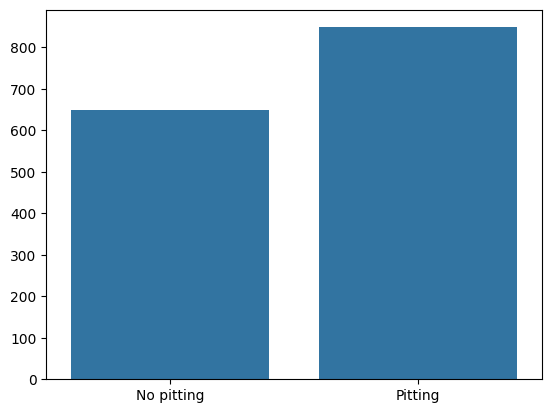

In [2]:
root = "../dataset_simplified"
# load the data
dataset = torchvision.datasets.ImageFolder(root=root)
# get the quantity of pitting and no pitting images
number_no_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["False"])[0])
number_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["True"])[0])

image_size = set()
image_mode = set()
# loop trough the dataset and 
for image, label in dataset:
    # use sets to only add unique values
    # check image size [width, height]
    image_size.add(image.size)
    # check the type of image e.g. RGB, grayscale
    # on first sight all images  seem to be RGB
    image_mode.add(image.mode)
    
# all images have the same size
print(image_size)
# all images are RGB => 3 channels
print(image_mode)
# plot the number of pitting and no pitting
sns.barplot(x=["No pitting", "Pitting"], y=[number_no_pitting, number_pitting])
plt.show()

<h2> Examine the distribution of the RGB values <h2>

In [6]:
r_values = []
g_values = []
b_values = []

for i, (img, _) in enumerate(dataset):
    img_np = np.array(img)
    if i == 0:
        print(img_np.shape)
        print(img_np)
        print(img_np[:, :, 0], img_np[:, :, 1], img_np[:, :, 2])
    r = img_np[:, :, 0]
    g = img_np[:, :, 1]
    b = img_np[:, :, 2]
    r_values.extend(r.flatten())
    g_values.extend(g.flatten())
    b_values.extend(b.flatten())
    
df = pd.DataFrame({
    'Red': r_values,
    'Green': g_values,
    'Blue': b_values
})

# Count outliers per channel
outlier_counts = {}
for channel in ['Red', 'Green', 'Blue']:
    print(channel)
    q1 = np.percentile(df[channel], 25)
    q3 = np.percentile(df[channel], 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[channel][(df[channel] < lower) | (df[channel] > upper)]
    outlier_counts[channel] = len(outliers)
    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, max_value: {int(df[channel].max())}, min_value: {int(df[channel].min())}")
    print(f"max_value is outlier for {(int(df[channel].max())-q3)/iqr}")
    print(f"min_value is outlier for {-(int(df[channel].min())-q1)/iqr}")

(150, 150, 3)
[[[119 107  69]
  [109  99  63]
  [106  96  61]
  ...
  [231 219 161]
  [236 225 169]
  [230 221 166]]

 [[120 108  70]
  [114 104  68]
  [104  94  59]
  ...
  [233 221 161]
  [232 221 165]
  [234 225 170]]

 [[118 106  68]
  [123 110  75]
  [107  94  60]
  ...
  [234 222 162]
  [233 222 166]
  [231 221 168]]

 ...

 [[140 124  75]
  [142 126  77]
  [146 130  81]
  ...
  [ 88  78  43]
  [ 92  82  47]
  [ 96  86  51]]

 [[138 122  73]
  [139 123  74]
  [143 127  78]
  ...
  [ 89  79  44]
  [ 87  77  42]
  [ 91  81  46]]

 [[136 120  71]
  [142 126  77]
  [143 127  78]
  ...
  [ 90  80  45]
  [ 89  79  44]
  [ 92  82  46]]]
[[119 109 106 ... 231 236 230]
 [120 114 104 ... 233 232 234]
 [118 123 107 ... 234 233 231]
 ...
 [140 142 146 ...  88  92  96]
 [138 139 143 ...  89  87  91]
 [136 142 143 ...  90  89  92]] [[107  99  96 ... 219 225 221]
 [108 104  94 ... 221 221 225]
 [106 110  94 ... 222 222 221]
 ...
 [124 126 130 ...  78  82  86]
 [122 123 127 ...  79  77  81]
 [12

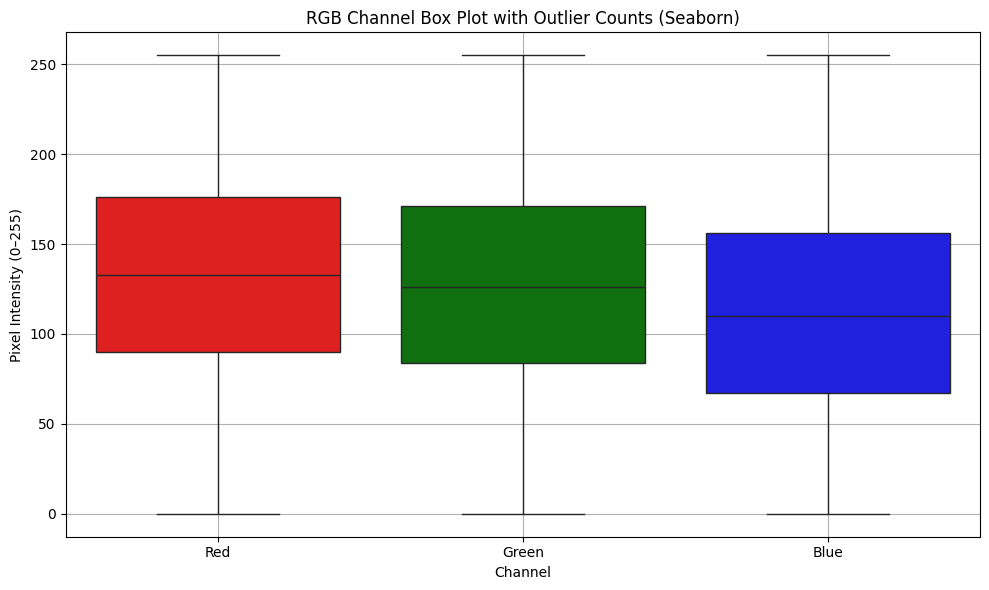

"\n# Annotate outlier counts\nfor i, channel in enumerate(['Red', 'Green', 'Blue']):\n    max_val = int(df[channel].max())\n    plt.text(i, max_val + 5, f'Outliers: {outlier_counts[channel]}',\n             ha='center', va='bottom', fontsize=10, color=channel.lower())\n"

In [ ]:
# Melt for Seaborn boxplot
df_melted = df.melt(var_name='Channel', value_name='Intensity')
# Plot with Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Channel', y='Intensity', hue='Channel', palette={'Red': 'red', 'Green': 'green', 'Blue': 'blue'}, legend=False)
plt.title('RGB Channel Box Plot with Outlier Counts (Seaborn)')
# Annotate outlier counts
for i, channel in enumerate(['Red', 'Green', 'Blue']):
    max_val = int(df[channel].max())
    plt.text(i, max_val + 5, f'Outliers: {outlier_counts[channel]}',
             ha='center', va='bottom', fontsize=10, color=channel.lower())
plt.ylabel('Pixel Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()

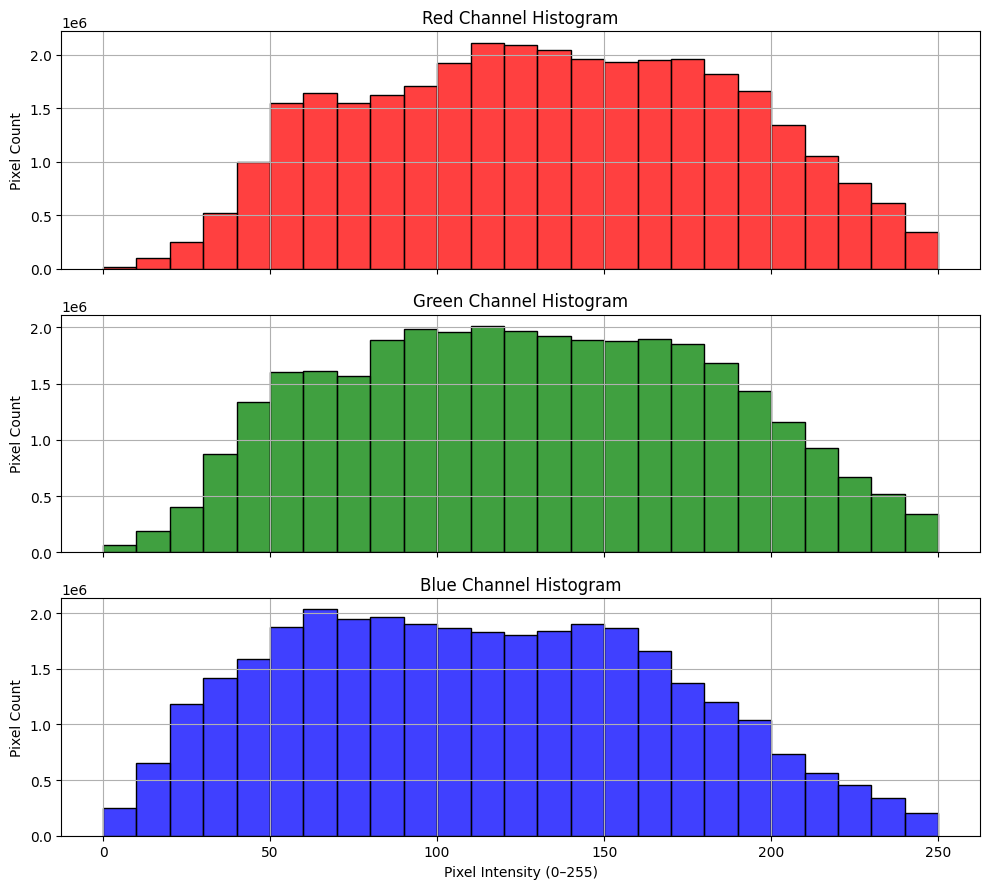

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

channels = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']
bins = np.arange(0, 257, 10)  # 64 bins

for ax, channel, color in zip(axs, channels, colors):
    sns.histplot(df[channel], bins=bins, color=color, ax=ax)
    ax.set_title(f'{channel} Channel Histogram')
    ax.set_ylabel('Pixel Count')
    ax.grid(True)

axs[-1].set_xlabel('Pixel Intensity (0–255)')
plt.tight_layout()
plt.show()

<h1> Preprocessing </h1>

<h2> Normalize images </h2>

In [3]:
def transform_images(angle=None, grayscale=False):
    # set up a pipeline for normalization
    # first all pixel values are scaled to [0.0, 1.0] and then normalized with x_new = (x-mean) / std where mean is the first tuple
    # and std is the second tuple for each of the 3 channels
    # if an angle is given the image is rotated by angle degrees
    if angle and grayscale:
        transform = transforms.Compose([
            transforms.Lambda(lambda img: rotate(img, angle=angle)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
    elif angle:
        transform = transforms.Compose([
            transforms.Lambda(lambda img: rotate(img, angle=angle)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    elif grayscale:
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
    else:
        transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    return torchvision.datasets.ImageFolder(root=root, transform=transform)


<h2> Load images </h2>

In [4]:
batch_size = 32
# load and normalize the data
dataset = transform_images(grayscale=grayscale)

<h2> Rotate images </h2>

In [5]:
if rotate_images == True:
    dataset_rotated_90 = transform_images(angle=90, grayscale=grayscale)
    dataset_rotated_180 = transform_images(angle=180, grayscale=grayscale)
    dataset_rotated_270 = transform_images(angle=270, grayscale=grayscale)
    dataset = torch.utils.data.ConcatDataset([dataset, dataset_rotated_90, dataset_rotated_180, dataset_rotated_270])
elif rotate_images == "random":
    dataset_rotated_90 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset_rotated_180 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset_rotated_270 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset = torch.utils.data.ConcatDataset([dataset, dataset_rotated_90, dataset_rotated_180, dataset_rotated_270])

In [6]:
"""
dataset = torchvision.datasets.ImageFolder(root=root, transform=None)

# Pick one image
img, label = dataset[0]  # img is a PIL.Image

# Rotate the image by 90 degrees
img_rotated = rotate(img, angle=40)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(img)
axs[0].set_title("Original")
axs[0].axis('off')

axs[1].imshow(img_rotated)
axs[1].set_title("Rotated 90°")
axs[1].axis('off')

plt.tight_layout()
plt.show()
"""

'\ndataset = torchvision.datasets.ImageFolder(root=root, transform=None)\n\n# Pick one image\nimg, label = dataset[0]  # img is a PIL.Image\n\n# Rotate the image by 90 degrees\nimg_rotated = rotate(img, angle=40)\n\nfig, axs = plt.subplots(1, 2, figsize=(8, 4))\naxs[0].imshow(img)\naxs[0].set_title("Original")\naxs[0].axis(\'off\')\n\naxs[1].imshow(img_rotated)\naxs[1].set_title("Rotated 90°")\naxs[1].axis(\'off\')\n\nplt.tight_layout()\nplt.show()\n'

In [6]:
# do a train test split with 80% train size
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset=dataset, lengths=[train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# False=no pitting, True=pitting
classes = ("False", "True")

In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 34 * 34, 2048)
        self.fc2 = nn.Linear(2048, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


net = Net()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [10]:
for epoch in range(10):  # loop over the dataset multiple times
    print(f"epoch {epoch}")
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

epoch 0
epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
Finished Training


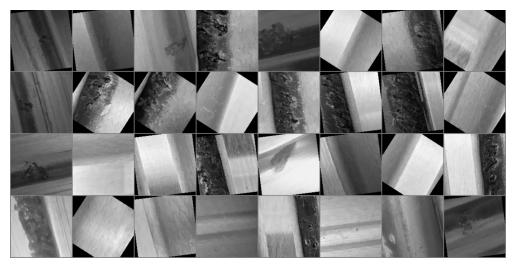

GroundTruth:  True  False True  True  True  False True  False True  True  True  False True  True  True  False True  False False True  True  False False True  True  False False False True  False False True 


In [11]:
images, labels = next(iter(test_loader))

# Make grid (tensor) from images
img_grid = torchvision.utils.make_grid(images)

# Convert tensor to numpy and rearrange axes for matplotlib (H, W, C)
npimg = img_grid.numpy().transpose((1, 2, 0))

# Unnormalize (reverse the normalization you applied)
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]
npimg = std * npimg + mean

# Clip values to valid range
npimg = np.clip(npimg, 0, 1)

plt.imshow(npimg)
plt.axis('off')
plt.show()

print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(len(images))))


In [12]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(len(images))))

Predicted:  True  True  True  True  True  False True  False False True  True  False True  True  True  False True  False False True  True  True  False True  False False False False True  False True  True 


Accuracy: 0.9098
Precision: 0.9184
Recall:    0.9184
F1 Score:  0.9184


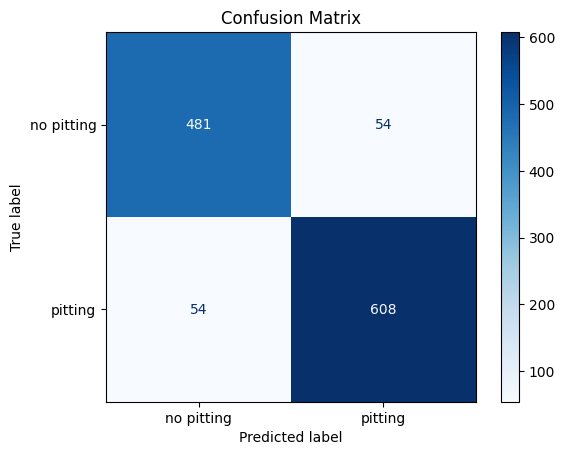

In [13]:
correct = 0
total = 0
all_preds = []
all_labels = []
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
cm = confusion_matrix(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
print(f"Accuracy: {accuracy:.4f}")
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no pitting", "pitting"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

<h2> GridSearchCV </h2>

In [14]:
X_train_list = []
y_train_list = []
for i in range(len(train_dataset)):
    data, label = train_dataset[i]
    X_train_list.append(data.numpy()) # Convert to NumPy array
    y_train_list.append(label) # Convert to NumPy array

X_train = np.array(X_train_list).astype(np.float32)
y_train = np.array(y_train_list).astype(np.int64)

# For test data
X_test_list = []
y_test_list = []
for i in range(len(test_dataset)):
    data, label = test_dataset[i]
    X_test_list.append(data.numpy())
    y_test_list.append(label)

X_test = np.array(X_test_list).astype(np.float32)
y_test = np.array(y_test_list).astype(np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")



net = NeuralNetClassifier(Net(), criterion=criterion, optimizer=optim.SGD, max_epochs=10, lr=0.01)

param_grid = {
    'lr': [0.01, 0.1],
    'max_epochs': [2, 3],
    #'module__dropout': [0.0, 0.2],
    'batch_size': [32],
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',       
    'f1': 'f1',               
}

grid_search = GridSearchCV(estimator=net, param_grid=param_grid, cv=StratifiedKFold(n_splits=5), scoring=scoring, refit="accuracy", n_jobs=-1, verbose=3)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Best Parameters and Score ---")
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy on cross-validation set: ", grid_search.best_score_)

print("\n--- Evaluation on Test Set (using the best model) ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro') # Use 'macro' for multi-class, or 'binary' for binary
recall = recall_score(y_test, y_pred, average='macro')     # Use 'macro' for multi-class, or 'binary' for binary
f1 = f1_score(y_test, y_pred, average='macro')             # Use 'macro' for multi-class, or 'binary' for binary

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

X_train shape: (1271, 3, 150, 150), y_train shape: (1271,)
X_test shape: (225, 3, 150, 150), y_test shape: (225,)
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7049       0.4265        0.6942  20.9017
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7052       0.4265        0.6945  21.1580
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7049       0.4265        0.6955  21.2195
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7047       0.4265        0.6939  21.4341
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1       

In [16]:
print("\n--- Detailed Cross-Validation Results  ---")
results = grid_search.cv_results_
# Sort by the refit metric (accuracy in this case)
sorted_indices = np.argsort(results['rank_test_accuracy'])
for i in sorted_indices:
    print(f"Rank {results['rank_test_accuracy'][i]}:")
    print(f"  Params: {results['params'][i]}")
    print(f"  Mean Accuracy: {results['mean_test_accuracy'][i]:.4f} (std: {results['std_test_accuracy'][i]:.4f})")
    print(f"  Mean Precision: {results['mean_test_precision'][i]:.4f} (std: {results['std_test_precision'][i]:.4f})")
    print(f"  Mean Recall: {results['mean_test_recall'][i]:.4f} (std: {results['std_test_recall'][i]:.4f})")
    print(f"  Mean F1-score: {results['mean_test_f1'][i]:.4f} (std: {results['std_test_f1'][i]:.4f})")
    print("-" * 30)


--- Detailed Cross-Validation Results  ---
Rank 1:
  Params: {'batch_size': 32, 'lr': 0.01, 'max_epochs': 2}
  Mean Accuracy: 0.8308 (std: 0.0301)
  Mean Precision: 0.8258 (std: 0.0281)
  Mean Recall: 0.8976 (std: 0.0593)
  Mean F1-score: 0.8587 (std: 0.0285)
------------------------------
Rank 2:
  Params: {'batch_size': 32, 'lr': 0.1, 'max_epochs': 2}
  Mean Accuracy: 0.8096 (std: 0.0645)
  Mean Precision: 0.8985 (std: 0.0374)
  Mean Recall: 0.7639 (std: 0.1520)
  Mean F1-score: 0.8125 (std: 0.0932)
------------------------------
Rank 3:
  Params: {'batch_size': 32, 'lr': 0.1, 'max_epochs': 3}
  Mean Accuracy: 0.7325 (std: 0.1463)
  Mean Precision: 0.9279 (std: 0.0448)
  Mean Recall: 0.5978 (std: 0.2913)
  Mean F1-score: 0.6661 (std: 0.2792)
------------------------------
Rank 4:
  Params: {'batch_size': 32, 'lr': 0.01, 'max_epochs': 3}
  Mean Accuracy: 0.6837 (std: 0.0403)
  Mean Precision: 0.6498 (std: 0.0360)
  Mean Recall: 0.9891 (std: 0.0153)
  Mean F1-score: 0.7834 (std: 0.020